# Analysis of 521.xlsx Dataset for Research Publication

This notebook provides comprehensive analysis and visualization of the 521.xlsx dataset, creating publication-ready charts and graphs suitable for research journals.

## 1. Import Required Libraries

Import all necessary libraries for data analysis and visualization.

In [1]:
# Import necessary libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import os

# Set style for publication-quality plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Configure matplotlib for high-quality output
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

Libraries imported successfully!
Pandas version: 2.3.2
Matplotlib version: 3.10.6
Seaborn version: 0.13.2


## 2. Load and Explore the Dataset

Load the 521.xlsx file and examine its structure and content.

In [2]:
# Load the Excel file
file_path = '521.xlsx'
try:
    # Try to read the Excel file
    df = pd.read_excel(file_path)
    print(f"Successfully loaded {file_path}")
    print(f"Dataset shape: {df.shape}")
    print("\n" + "="*50)
    
    # Display basic information about the dataset
    print("DATASET OVERVIEW:")
    print("="*50)
    print(f"Number of rows: {df.shape[0]}")
    print(f"Number of columns: {df.shape[1]}")
    print(f"Column names: {list(df.columns)}")
    
except FileNotFoundError:
    print(f"Error: File '{file_path}' not found. Please check the file path.")
except Exception as e:
    print(f"Error loading file: {e}")

Successfully loaded 521.xlsx
Dataset shape: (331, 10)

DATASET OVERVIEW:
Number of rows: 331
Number of columns: 10
Column names: ['Patient name', 'Age', 'Brand name', 'Generic name', 'Company', 'Area', 'Medical center', 'Gender', 'Doctor specialization', 'Symptoms']


In [3]:
# Display first few rows of the dataset
print("FIRST 5 ROWS:")
print("="*50)
display(df.head())

print("\nLAST 5 ROWS:")
print("="*30)
display(df.tail())

print("\nDATA TYPES:")
print("="*30)
print(df.dtypes)

print("\nCOLUMN INFORMATION:")
print("="*40)
df.info()

FIRST 5 ROWS:


,Patient name,Age,Brand name,Generic name,Company,Area,Medical center,Gender,Doctor specialization,Symptoms
0,Ms. Irin,45,zasper 20mg,esomeprazole,Maks Drug Limited,chattogram,park view hospital limited,female,Orthopedic,knee pain
1,Mr. haripala,65,sergel 20mg,esomeprazole,Healthcare,chattogram,eagle's eye diagnostic,male,dermatologist,ringworm
2,Josna akhter,40,maxpro 20mg,esomeprazole,Renata PLC,chattogram,epic healthcare,female,physical medicine and rehab,"low back pain, heel pain"
3,Prya das,28,sergel 20mg,esomeprazole,Healthcare,chattogram,epic healthcare,female,physical medicine and rehab,inflammatory polyarthritis
4,Mrs. Rowshan ara begum,52,pantomak 20mg,pantoprazole sodium,Maks Drug Limited,chattogram,park view hospital limited,female,cardiologist,chest pain



LAST 5 ROWS:


,Patient name,Age,Brand name,Generic name,Company,Area,Medical center,Gender,Doctor specialization,Symptoms
326,md kasem,47,rabe 20mg,Rabeprazole Sodium,aristopharma,chattogram,park view hospital limited,male,cardiologist,chest pain
327,minu ara,37,Pantonix 20mg,Pantoprazole Sodium,incepta,chattogram,park view hospital limited,female,cardiologist,"Ischemic Heart Disease, dm"
328,mrs rahima,17,exium mups 20mg,Esomeprazole,radiant,chattogram,park view hospital limited,female,rheumatologist,axial spondyloarthritis
329,mrs samuda begum,50,canalia 30mg,Dexlansoprazole,aristopharma,chattogram,park view hospital limited,female,rheumatologist,rheumatoid arthritis
330,mrs rowshan akther,54,Dexilend 30mg,Dexlansoprazole,Ziska,chattogram,park view hospital limited,female,rheumatologist,"lumber radiculopathy, obesity, iron deficiency..."



DATA TYPES:
Patient name             object
Age                       int64
Brand name               object
Generic name             object
Company                  object
Area                     object
Medical center           object
Gender                   object
Doctor specialization    object
Symptoms                 object
dtype: object

COLUMN INFORMATION:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331 entries, 0 to 330
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Patient name           331 non-null    object
 1   Age                    331 non-null    int64 
 2   Brand name             331 non-null    object
 3   Generic name           331 non-null    object
 4   Company                331 non-null    object
 5   Area                   331 non-null    object
 6   Medical center         331 non-null    object
 7   Gender                 331 non-null    object
 8   Doctor speci

## 3. Data Cleaning and Preprocessing

Check for missing values, duplicates, and prepare data for analysis.

In [4]:
# Check for missing values
print("MISSING VALUES ANALYSIS:")
print("="*50)
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing Count': missing_values.values,
    'Missing Percentage': missing_percentage.values
})
print(missing_df[missing_df['Missing Count'] > 0])

# Check for duplicates
print(f"\nDUPLICATE ROWS: {df.duplicated().sum()}")

# Basic statistics for numerical columns
print("\nNUMERICAL COLUMNS SUMMARY:")
print("="*50)
numerical_cols = df.select_dtypes(include=[np.number]).columns
if len(numerical_cols) > 0:
    display(df[numerical_cols].describe())
else:
    print("No numerical columns found.")

# Check categorical columns
print("\nCATEGORICAL COLUMNS:")
print("="*30)
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"Categorical columns: {list(categorical_cols)}")

for col in categorical_cols:
    print(f"\n{col} - Unique values: {df[col].nunique()}")
    if df[col].nunique() <= 20:  # Display unique values if not too many
        print(f"Values: {df[col].unique()}")

MISSING VALUES ANALYSIS:
Empty DataFrame
Columns: [Column, Missing Count, Missing Percentage]
Index: []

DUPLICATE ROWS: 2

NUMERICAL COLUMNS SUMMARY:


,Age
count,331.000000
mean,45.725076
std,14.838319
min,12.000000
25%,35.000000
50%,46.000000
75%,55.000000
max,90.000000



CATEGORICAL COLUMNS:
Categorical columns: ['Patient name', 'Brand name', 'Generic name', 'Company', 'Area', 'Medical center', 'Gender', 'Doctor specialization', 'Symptoms']

Patient name - Unique values: 309

Brand name - Unique values: 30

Generic name - Unique values: 9
Values: ['esomeprazole' 'pantoprazole sodium' 'famotidien' 'dexlansoprazole'
 'Rabeprazole Sodium' 'omeprazole' 'Dexlansoprazole' 'Pantoprazole Sodium'
 'Esomeprazole']

Company - Unique values: 20
Values: ['Maks Drug Limited' 'Healthcare' 'Renata PLC' 'radiant' 'acme' 'skf'
 'square' 'aristopharma' 'aci' 'opsonin' 'beximco' 'incepta' 'Ziska'
 'Incepta' 'Opsonin' 'pacific pharmaceuticals' 'popular pharmaceuticals'
 'sandoz' 'ibn sina pharmaceuticals' 'sun pharmaceuticals']

Area - Unique values: 1
Values: ['chattogram']

Medical center - Unique values: 6
Values: ['park view hospital limited' "eagle's eye diagnostic" 'epic healthcare'
 'ibn sina' 'revive' 'chittagong medical college']

Gender - Unique values: 3
Values

## 4. Descriptive Statistics Analysis

Calculate summary statistics and identify key patterns in the data.

In [5]:
# Calculate correlation matrix for numerical variables
if len(numerical_cols) > 1:
    print("CORRELATION MATRIX:")
    print("="*30)
    correlation_matrix = df[numerical_cols].corr()
    display(correlation_matrix)
    
    # Find highly correlated pairs
    print("\nHIGHLY CORRELATED PAIRS (|correlation| > 0.7):")
    print("="*55)
    high_corr_pairs = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            corr_val = correlation_matrix.iloc[i, j]
            if abs(corr_val) > 0.7:
                high_corr_pairs.append((
                    correlation_matrix.columns[i], 
                    correlation_matrix.columns[j], 
                    corr_val
                ))
    
    for pair in high_corr_pairs:
        print(f"{pair[0]} <-> {pair[1]}: {pair[2]:.3f}")
    
    if not high_corr_pairs:
        print("No highly correlated pairs found.")

# Value counts for categorical variables
print("\nCATEGORICAL VARIABLE DISTRIBUTIONS:")
print("="*50)
for col in categorical_cols:
    print(f"\n{col}:")
    print("-" * len(col))
    value_counts = df[col].value_counts()
    if len(value_counts) <= 15:  # Display if not too many categories
        print(value_counts)
    else:
        print(f"Too many categories ({len(value_counts)}). Top 10:")
        print(value_counts.head(10))


CATEGORICAL VARIABLE DISTRIBUTIONS:

Patient name:
------------
Too many categories (309). Top 10:
Patient name
monowara begum     4
selina akther      3
hamida begum       3
yasmin akther      2
taslima akther     2
monjura begum      2
md ismail          2
hosne ara begum    2
jahanara begum     2
babul miya         2
Name: count, dtype: int64

Brand name:
----------
Too many categories (30). Top 10:
Brand name
esoral mups 20mg    99
sergel 20mg         53
exium mups 20mg     31
Pantonix 20mg       24
maxpro 20mg         21
canalia 30mg        14
Dexilend 30mg       11
lanso d 30mg        10
othera 20mg          9
rabe 20mg            8
Name: count, dtype: int64

Generic name:
------------
Generic name
esomeprazole           214
Pantoprazole Sodium     26
Esomeprazole            23
dexlansoprazole         21
Rabeprazole Sodium      19
Dexlansoprazole         19
pantoprazole sodium      4
famotidien               3
omeprazole               2
Name: count, dtype: int64

Company:
------

## 5. Create Data Visualizations

Generate various types of plots to visualize data distributions and relationships.

In [10]:
# Create a directory for saving plots
output_dir = Path("analysis_plots")
output_dir.mkdir(exist_ok=True)

# Function to save plots
def save_plot(filename, fig=None, bbox_inches='tight', dpi=300):
    """Save plot in multiple formats"""
    if fig is None:
        fig = plt.gcf()
    
    # Save as PNG and PDF
    fig.savefig(output_dir / f"{filename}.png", bbox_inches=bbox_inches, dpi=dpi)
    fig.savefig(output_dir / f"{filename}.pdf", bbox_inches=bbox_inches, dpi=dpi)
    print(f"Plot saved as {filename}.png and {filename}.pdf")

print(f"Output directory created: {output_dir.absolute()}")

Output directory created: /home/dodopc/Documents/bijoy/analysis_plots


Plot saved as numerical_distributions.png and numerical_distributions.pdf


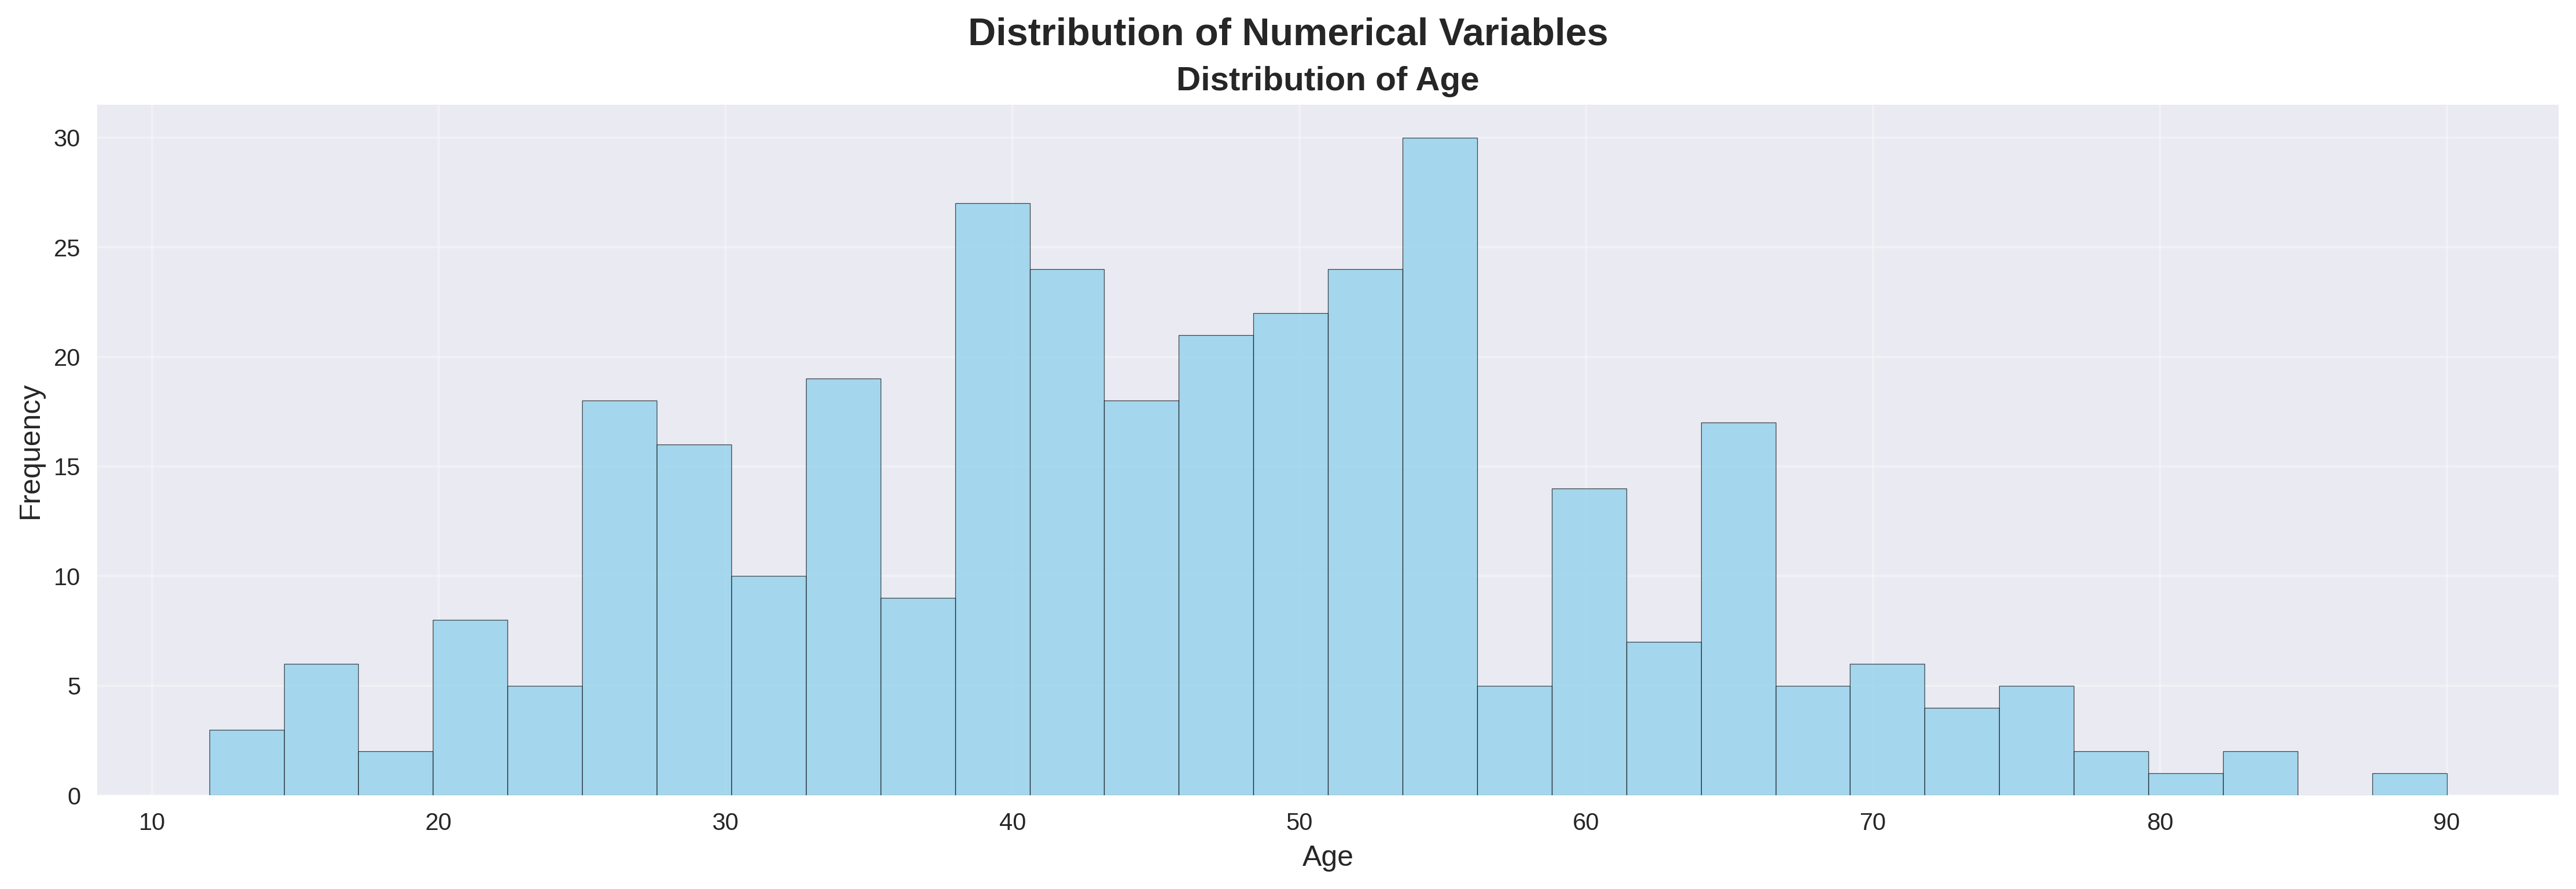

In [7]:
# Plot 1: Histograms for numerical variables
if len(numerical_cols) > 0:
    n_cols = min(3, len(numerical_cols))
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    if len(numerical_cols) == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for i, col in enumerate(numerical_cols):
        if i < len(axes):
            axes[i].hist(df[col].dropna(), bins=30, alpha=0.7, color='skyblue', edgecolor='black')
            axes[i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold')
            axes[i].set_xlabel(col, fontsize=12)
            axes[i].set_ylabel('Frequency', fontsize=12)
            axes[i].grid(True, alpha=0.3)
    
    # Hide unused subplots
    for i in range(len(numerical_cols), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.suptitle('Distribution of Numerical Variables', fontsize=16, fontweight='bold', y=1.02)
    save_plot("numerical_distributions", fig)
    plt.show()
else:
    print("No numerical columns to plot histograms.")

Plot saved as categorical_distributions.png and categorical_distributions.pdf


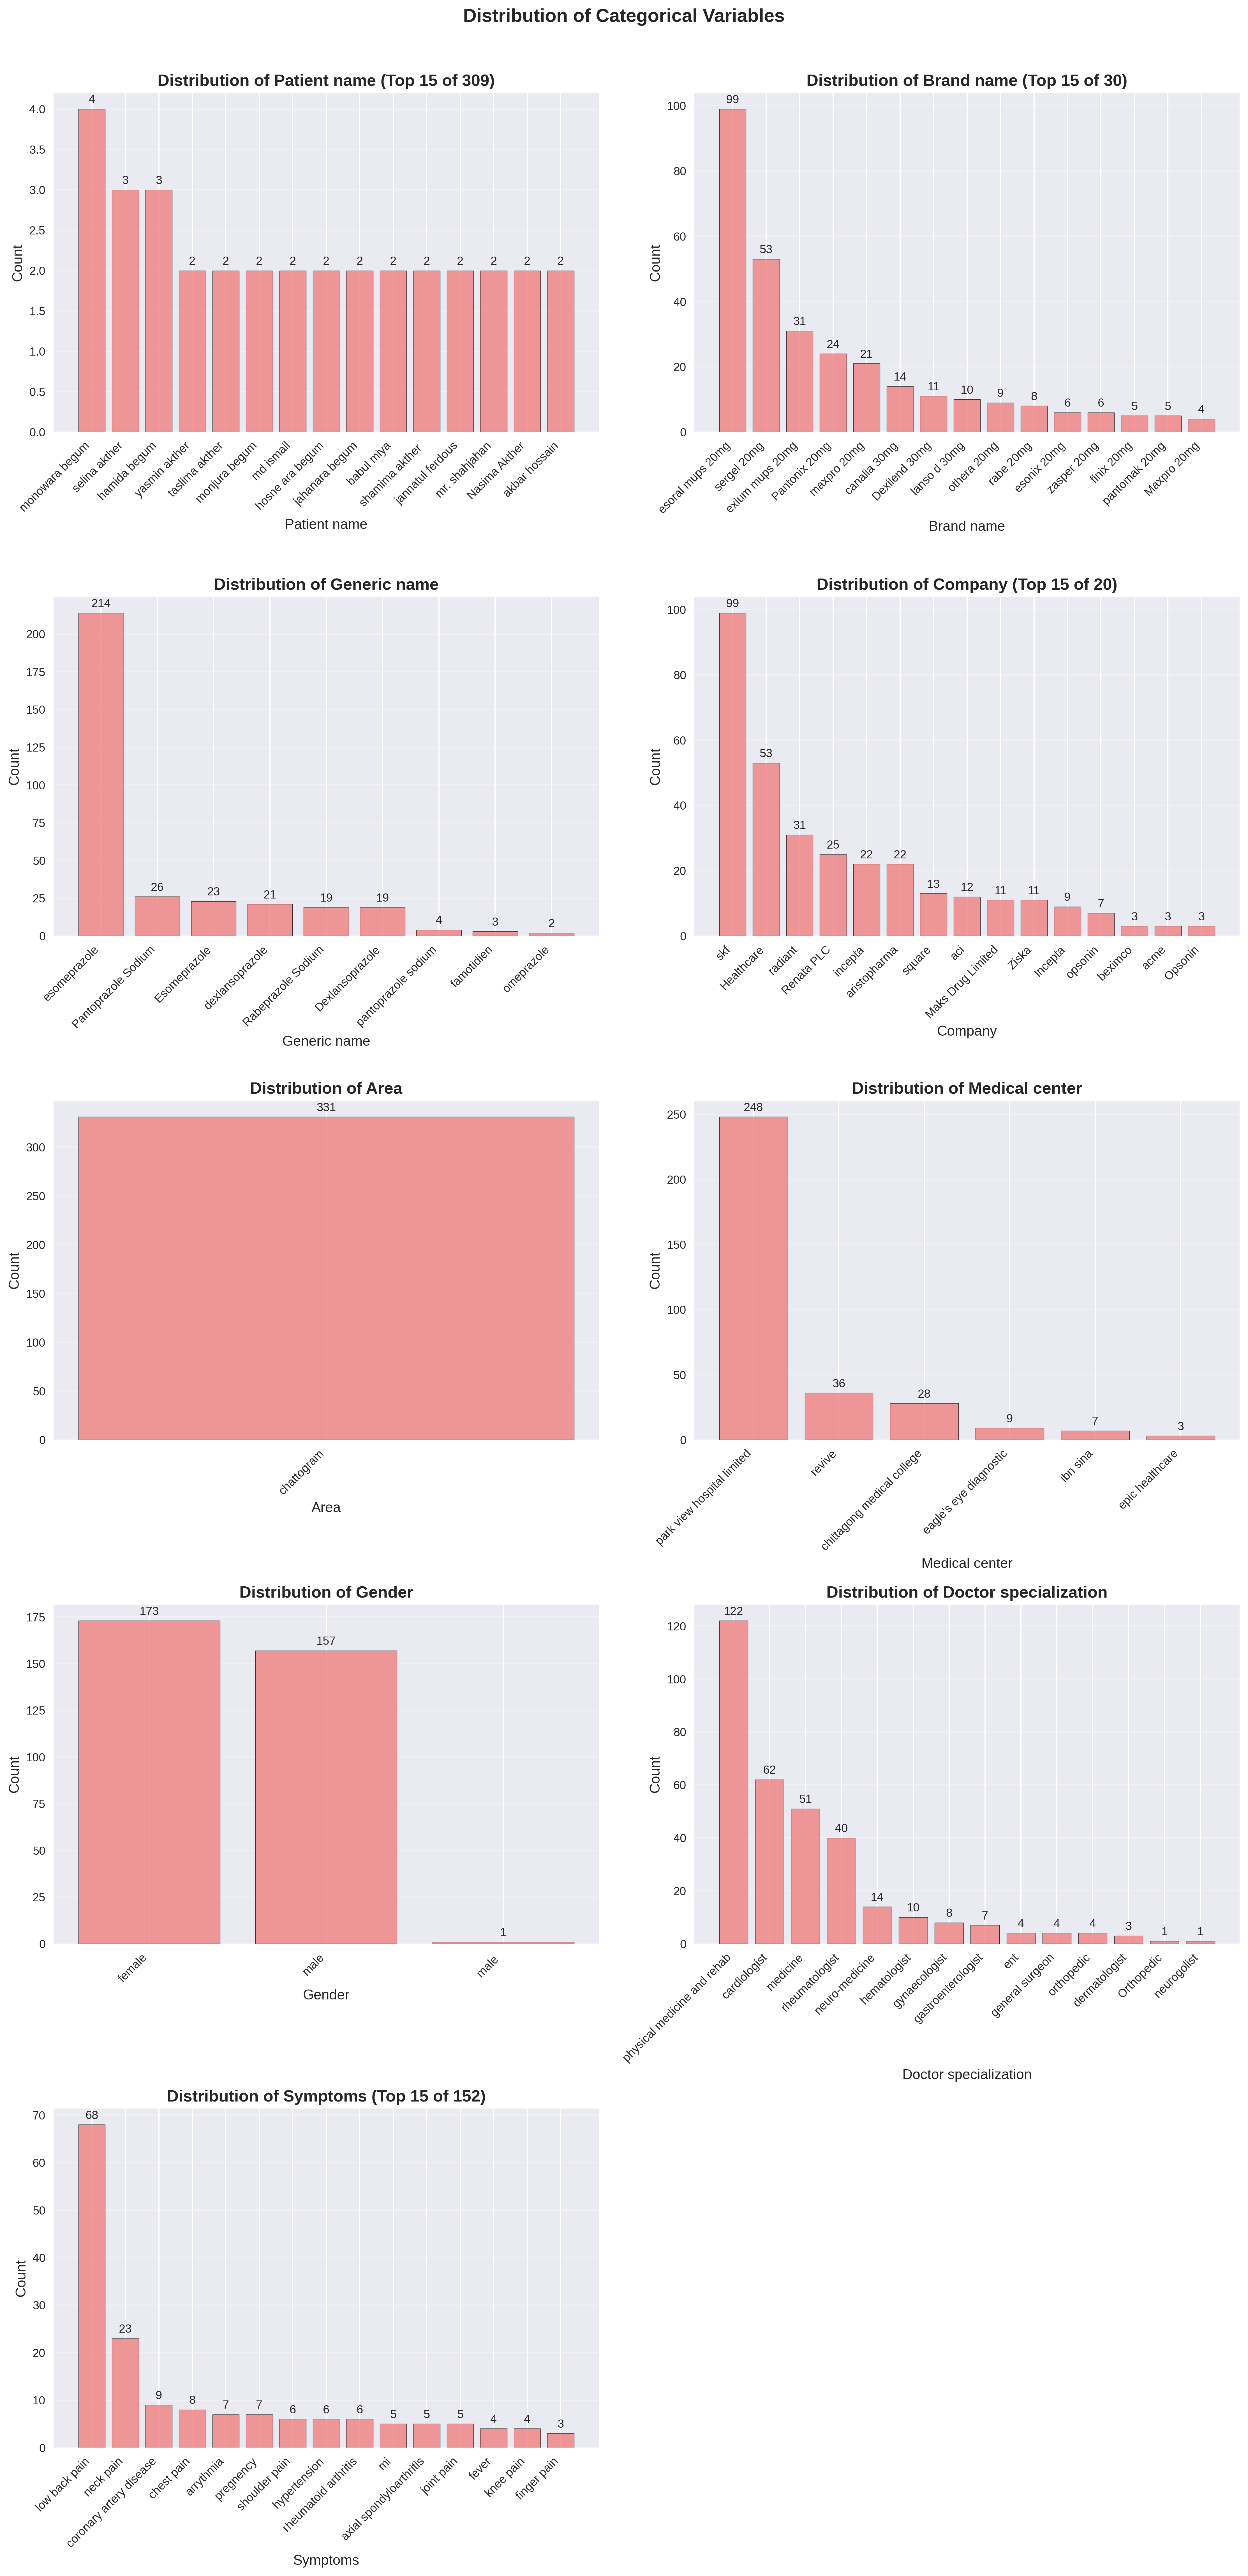

In [8]:
# Plot 2: Bar charts for categorical variables
if len(categorical_cols) > 0:
    n_cols = min(2, len(categorical_cols))
    n_rows = (len(categorical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6*n_rows))
    if len(categorical_cols) == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for i, col in enumerate(categorical_cols):
        if i < len(axes):
            value_counts = df[col].value_counts()
            
            # Limit to top 15 categories if too many
            if len(value_counts) > 15:
                value_counts = value_counts.head(15)
                title_suffix = f" (Top 15 of {df[col].nunique()})"
            else:
                title_suffix = ""
            
            bars = axes[i].bar(range(len(value_counts)), value_counts.values, 
                              color='lightcoral', alpha=0.8, edgecolor='black')
            axes[i].set_title(f'Distribution of {col}{title_suffix}', fontsize=14, fontweight='bold')
            axes[i].set_xlabel(col, fontsize=12)
            axes[i].set_ylabel('Count', fontsize=12)
            axes[i].set_xticks(range(len(value_counts)))
            axes[i].set_xticklabels(value_counts.index, rotation=45, ha='right')
            axes[i].grid(True, alpha=0.3, axis='y')
            
            # Add value labels on bars
            for bar, value in zip(bars, value_counts.values):
                axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(value_counts)*0.01,
                           str(value), ha='center', va='bottom', fontsize=10)
    
    # Hide unused subplots
    for i in range(len(categorical_cols), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.suptitle('Distribution of Categorical Variables', fontsize=16, fontweight='bold', y=1.02)
    save_plot("categorical_distributions", fig)
    plt.show()
else:
    print("No categorical columns to plot.")

In [11]:
# Plot 3: Correlation heatmap for numerical variables
if len(numerical_cols) > 1:
    plt.figure(figsize=(12, 10))
    correlation_matrix = df[numerical_cols].corr()
    
    # Create heatmap
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, 
                annot=True, 
                cmap='coolwarm', 
                center=0,
                square=True,
                mask=mask,
                cbar_kws={"shrink": .8},
                fmt='.3f',
                linewidths=0.5)
    
    plt.title('Correlation Matrix of Numerical Variables', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    save_plot("correlation_heatmap")
    plt.show()
else:
    print("Need at least 2 numerical columns for correlation heatmap.")

Need at least 2 numerical columns for correlation heatmap.


Plot saved as box_plots.png and box_plots.pdf


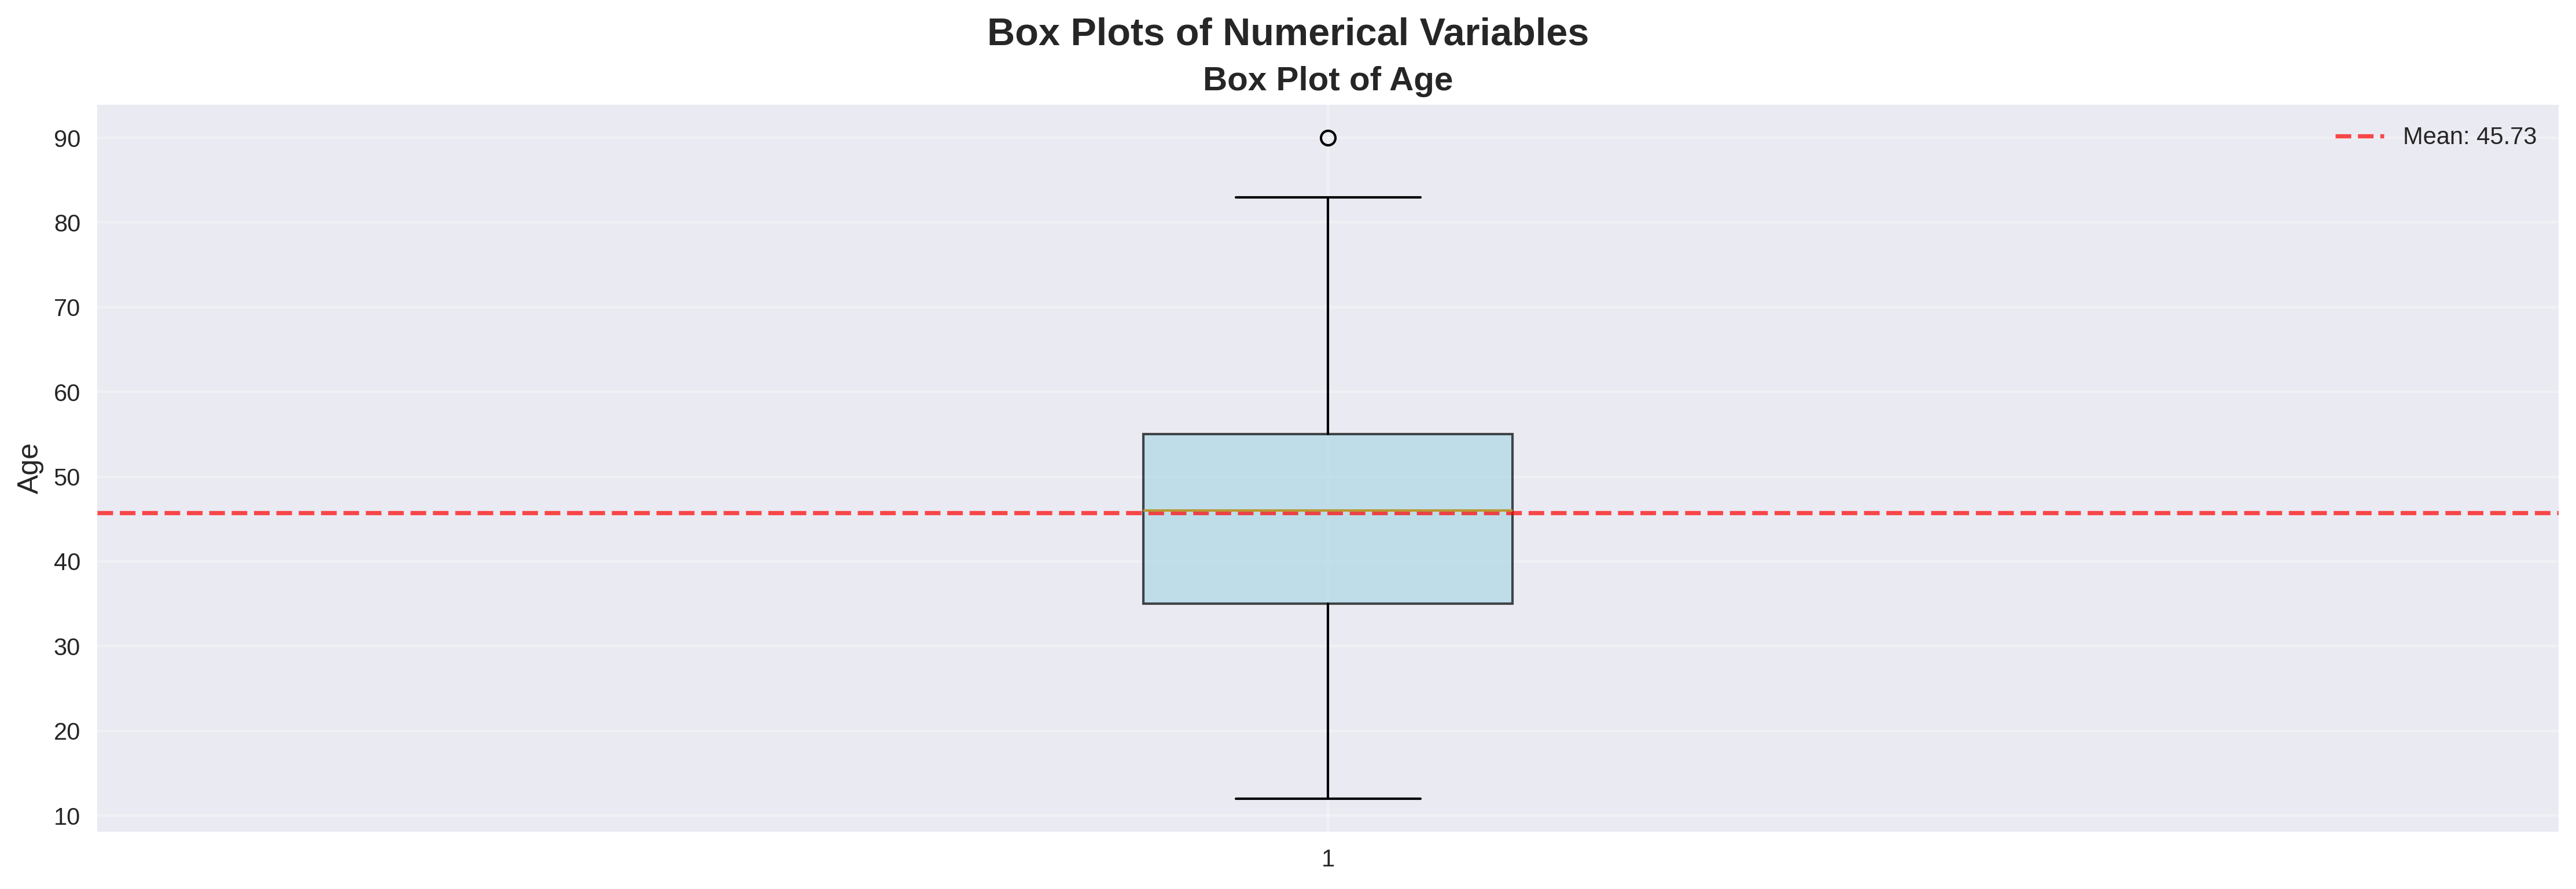

In [12]:
# Plot 4: Box plots for numerical variables
if len(numerical_cols) > 0:
    n_cols = min(3, len(numerical_cols))
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    if len(numerical_cols) == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for i, col in enumerate(numerical_cols):
        if i < len(axes):
            box_plot = axes[i].boxplot(df[col].dropna(), patch_artist=True)
            # Customize box plot colors
            box_plot['boxes'][0].set_facecolor('lightblue')
            box_plot['boxes'][0].set_alpha(0.7)
            
            axes[i].set_title(f'Box Plot of {col}', fontsize=14, fontweight='bold')
            axes[i].set_ylabel(col, fontsize=12)
            axes[i].grid(True, alpha=0.3)
            
            # Add mean line
            mean_val = df[col].mean()
            axes[i].axhline(y=mean_val, color='red', linestyle='--', alpha=0.7, label=f'Mean: {mean_val:.2f}')
            axes[i].legend()
    
    # Hide unused subplots
    for i in range(len(numerical_cols), len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    plt.suptitle('Box Plots of Numerical Variables', fontsize=16, fontweight='bold', y=1.02)
    save_plot("box_plots", fig)
    plt.show()
else:
    print("No numerical columns for box plots.")

In [13]:
# Plot 5: Scatter plots for numerical variable pairs
if len(numerical_cols) >= 2:
    # Create scatter plot matrix for up to 4 variables
    plot_cols = numerical_cols[:4] if len(numerical_cols) > 4 else numerical_cols
    
    if len(plot_cols) >= 2:
        # Create pairwise scatter plots
        from itertools import combinations
        pairs = list(combinations(plot_cols, 2))
        
        n_pairs = len(pairs)
        n_cols = min(3, n_pairs)
        n_rows = (n_pairs + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
        if n_pairs == 1:
            axes = [axes]
        elif n_rows == 1:
            axes = [axes]
        else:
            axes = axes.flatten()
        
        for i, (col1, col2) in enumerate(pairs):
            if i < len(axes):
                # Remove NaN values for the pair
                clean_data = df[[col1, col2]].dropna()
                
                axes[i].scatter(clean_data[col1], clean_data[col2], 
                              alpha=0.6, color='green', s=50, edgecolors='black', linewidth=0.5)
                axes[i].set_xlabel(col1, fontsize=12)
                axes[i].set_ylabel(col2, fontsize=12)
                axes[i].set_title(f'{col1} vs {col2}', fontsize=14, fontweight='bold')
                axes[i].grid(True, alpha=0.3)
                
                # Add correlation coefficient to the plot
                if len(clean_data) > 1:
                    corr_coef = clean_data[col1].corr(clean_data[col2])
                    axes[i].text(0.05, 0.95, f'r = {corr_coef:.3f}', 
                               transform=axes[i].transAxes, 
                               bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                               fontsize=11, fontweight='bold')
        
        # Hide unused subplots
        for i in range(n_pairs, len(axes)):
            axes[i].set_visible(False)
        
        plt.tight_layout()
        plt.suptitle('Scatter Plots of Numerical Variable Pairs', fontsize=16, fontweight='bold', y=1.02)
        save_plot("scatter_plots", fig)
        plt.show()
else:
    print("Need at least 2 numerical columns for scatter plots.")

Need at least 2 numerical columns for scatter plots.


## 6. Generate Charts for Research Publication

Create publication-ready charts with proper formatting and styling.

Plot saved as publication_overview.png and publication_overview.pdf


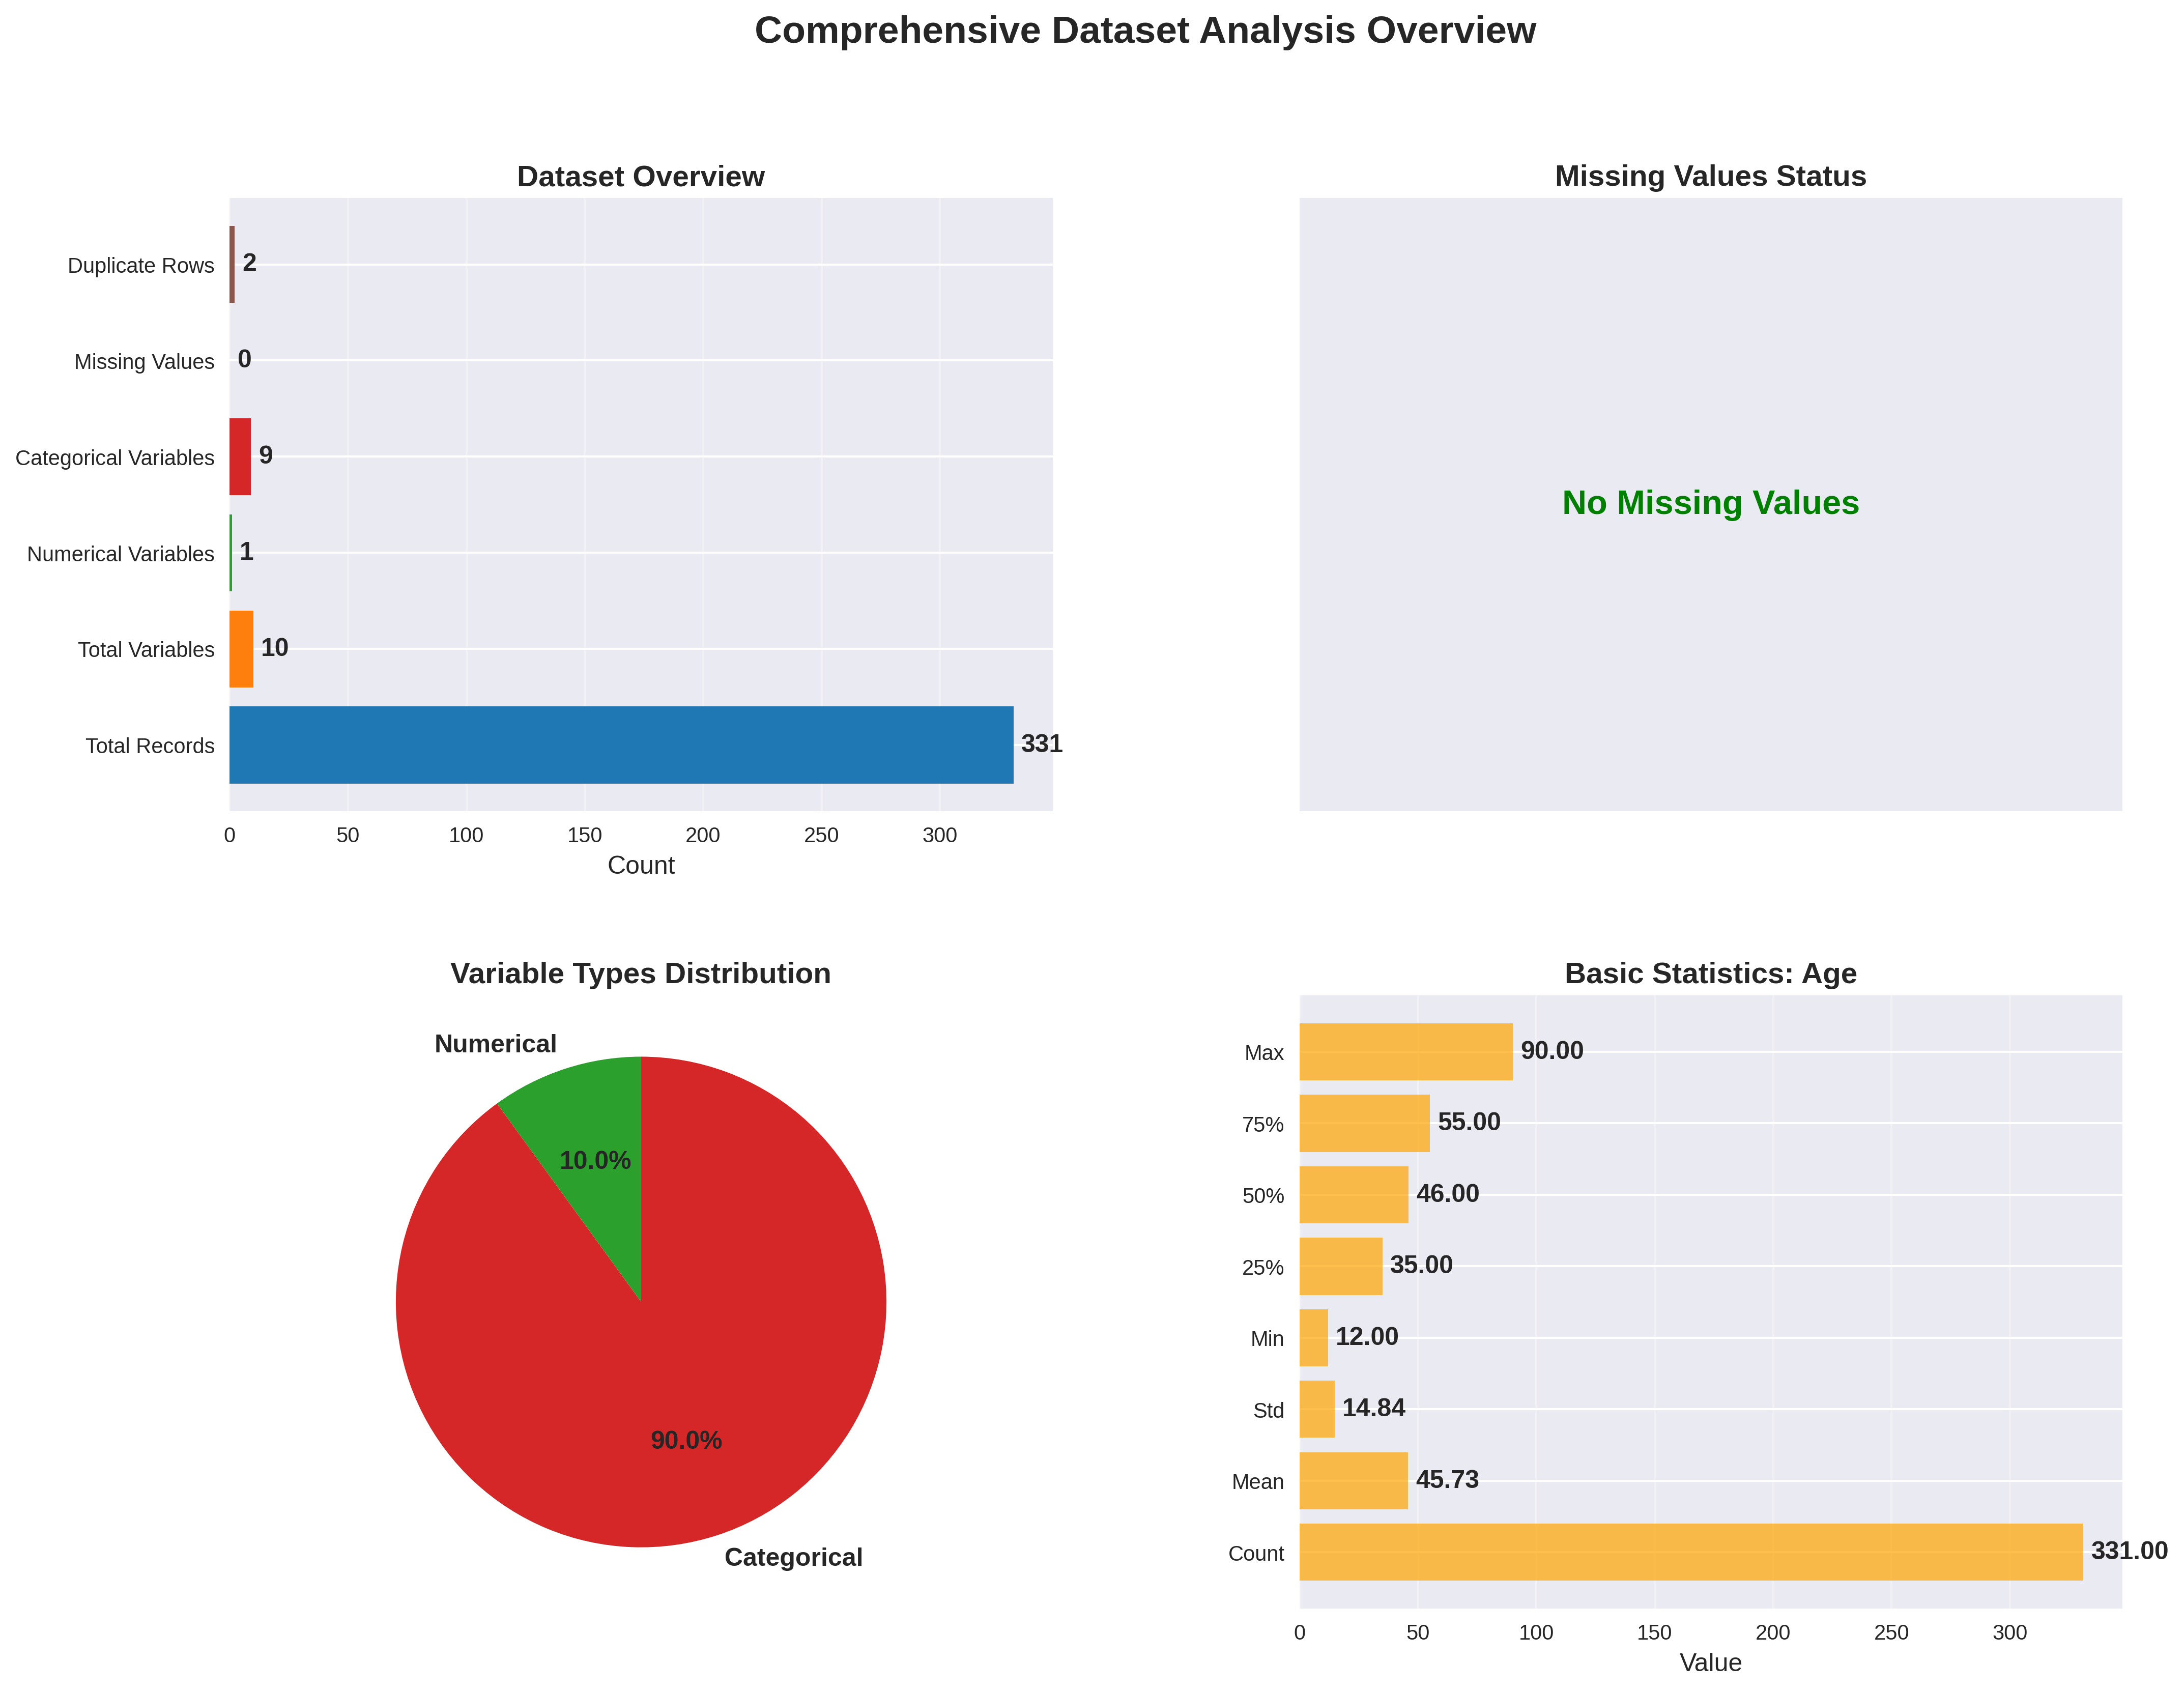

In [14]:
# Publication-ready figure 1: Combined overview
fig = plt.figure(figsize=(16, 12))

# Create a 2x2 subplot layout
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# Subplot 1: Data overview (top-left)
ax1 = fig.add_subplot(gs[0, 0])
data_info = [
    f"Total Records: {len(df)}",
    f"Total Variables: {len(df.columns)}",
    f"Numerical Variables: {len(numerical_cols)}",
    f"Categorical Variables: {len(categorical_cols)}",
    f"Missing Values: {df.isnull().sum().sum()}",
    f"Duplicate Rows: {df.duplicated().sum()}"
]

y_pos = np.arange(len(data_info))
ax1.barh(y_pos, [len(df), len(df.columns), len(numerical_cols), 
                 len(categorical_cols), df.isnull().sum().sum(), df.duplicated().sum()],
         color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b'])

ax1.set_yticks(y_pos)
ax1.set_yticklabels([info.split(':')[0] for info in data_info])
ax1.set_xlabel('Count')
ax1.set_title('Dataset Overview', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, v in enumerate([len(df), len(df.columns), len(numerical_cols), 
                       len(categorical_cols), df.isnull().sum().sum(), df.duplicated().sum()]):
    ax1.text(v + max(len(df), len(df.columns)) * 0.01, i, str(v), 
             va='center', fontweight='bold')

# Subplot 2: Missing values heatmap (top-right)
ax2 = fig.add_subplot(gs[0, 1])
if df.isnull().sum().sum() > 0:
    missing_data = df.isnull().sum()
    missing_data = missing_data[missing_data > 0]
    if len(missing_data) > 0:
        bars = ax2.bar(range(len(missing_data)), missing_data.values, color='red', alpha=0.7)
        ax2.set_xticks(range(len(missing_data)))
        ax2.set_xticklabels(missing_data.index, rotation=45, ha='right')
        ax2.set_ylabel('Missing Values Count')
        ax2.set_title('Missing Values by Column', fontsize=14, fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='y')
        
        # Add value labels
        for bar, value in zip(bars, missing_data.values):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(missing_data)*0.01,
                    str(value), ha='center', va='bottom', fontweight='bold')
    else:
        ax2.text(0.5, 0.5, 'No Missing Values', ha='center', va='center', 
                transform=ax2.transAxes, fontsize=16, fontweight='bold', color='green')
        ax2.set_title('Missing Values Status', fontsize=14, fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'No Missing Values', ha='center', va='center', 
            transform=ax2.transAxes, fontsize=16, fontweight='bold', color='green')
    ax2.set_title('Missing Values Status', fontsize=14, fontweight='bold')

# Remove axes if no missing values
if df.isnull().sum().sum() == 0:
    ax2.set_xticks([])
    ax2.set_yticks([])

# Subplot 3: Variable types distribution (bottom-left)
ax3 = fig.add_subplot(gs[1, 0])
var_types = ['Numerical', 'Categorical']
var_counts = [len(numerical_cols), len(categorical_cols)]
colors = ['#2ca02c', '#d62728']

wedges, texts, autotexts = ax3.pie(var_counts, labels=var_types, colors=colors, autopct='%1.1f%%',
                                   startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})

ax3.set_title('Variable Types Distribution', fontsize=14, fontweight='bold')

# Subplot 4: Sample size information (bottom-right)
ax4 = fig.add_subplot(gs[1, 1])
if len(numerical_cols) > 0:
    # Show basic statistics for the first numerical column
    first_num_col = numerical_cols[0]
    stats = df[first_num_col].describe()
    
    stat_names = ['Count', 'Mean', 'Std', 'Min', '25%', '50%', '75%', 'Max']
    stat_values = [stats['count'], stats['mean'], stats['std'], stats['min'],
                   stats['25%'], stats['50%'], stats['75%'], stats['max']]
    
    y_pos = np.arange(len(stat_names))
    bars = ax4.barh(y_pos, stat_values, color='orange', alpha=0.7)
    ax4.set_yticks(y_pos)
    ax4.set_yticklabels(stat_names)
    ax4.set_xlabel('Value')
    ax4.set_title(f'Basic Statistics: {first_num_col}', fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='x')
    
    # Add value labels
    for i, v in enumerate(stat_values):
        ax4.text(v + max(stat_values) * 0.01, i, f'{v:.2f}', 
                va='center', fontweight='bold')
else:
    ax4.text(0.5, 0.5, 'No Numerical\nVariables\nfor Statistics', 
            ha='center', va='center', transform=ax4.transAxes, 
            fontsize=14, fontweight='bold')
    ax4.set_xticks([])
    ax4.set_yticks([])
    ax4.set_title('Statistical Overview', fontsize=14, fontweight='bold')

plt.suptitle('Comprehensive Dataset Analysis Overview', fontsize=18, fontweight='bold', y=0.98)
save_plot("publication_overview", fig)
plt.show()

Plot saved as publication_advanced.png and publication_advanced.pdf


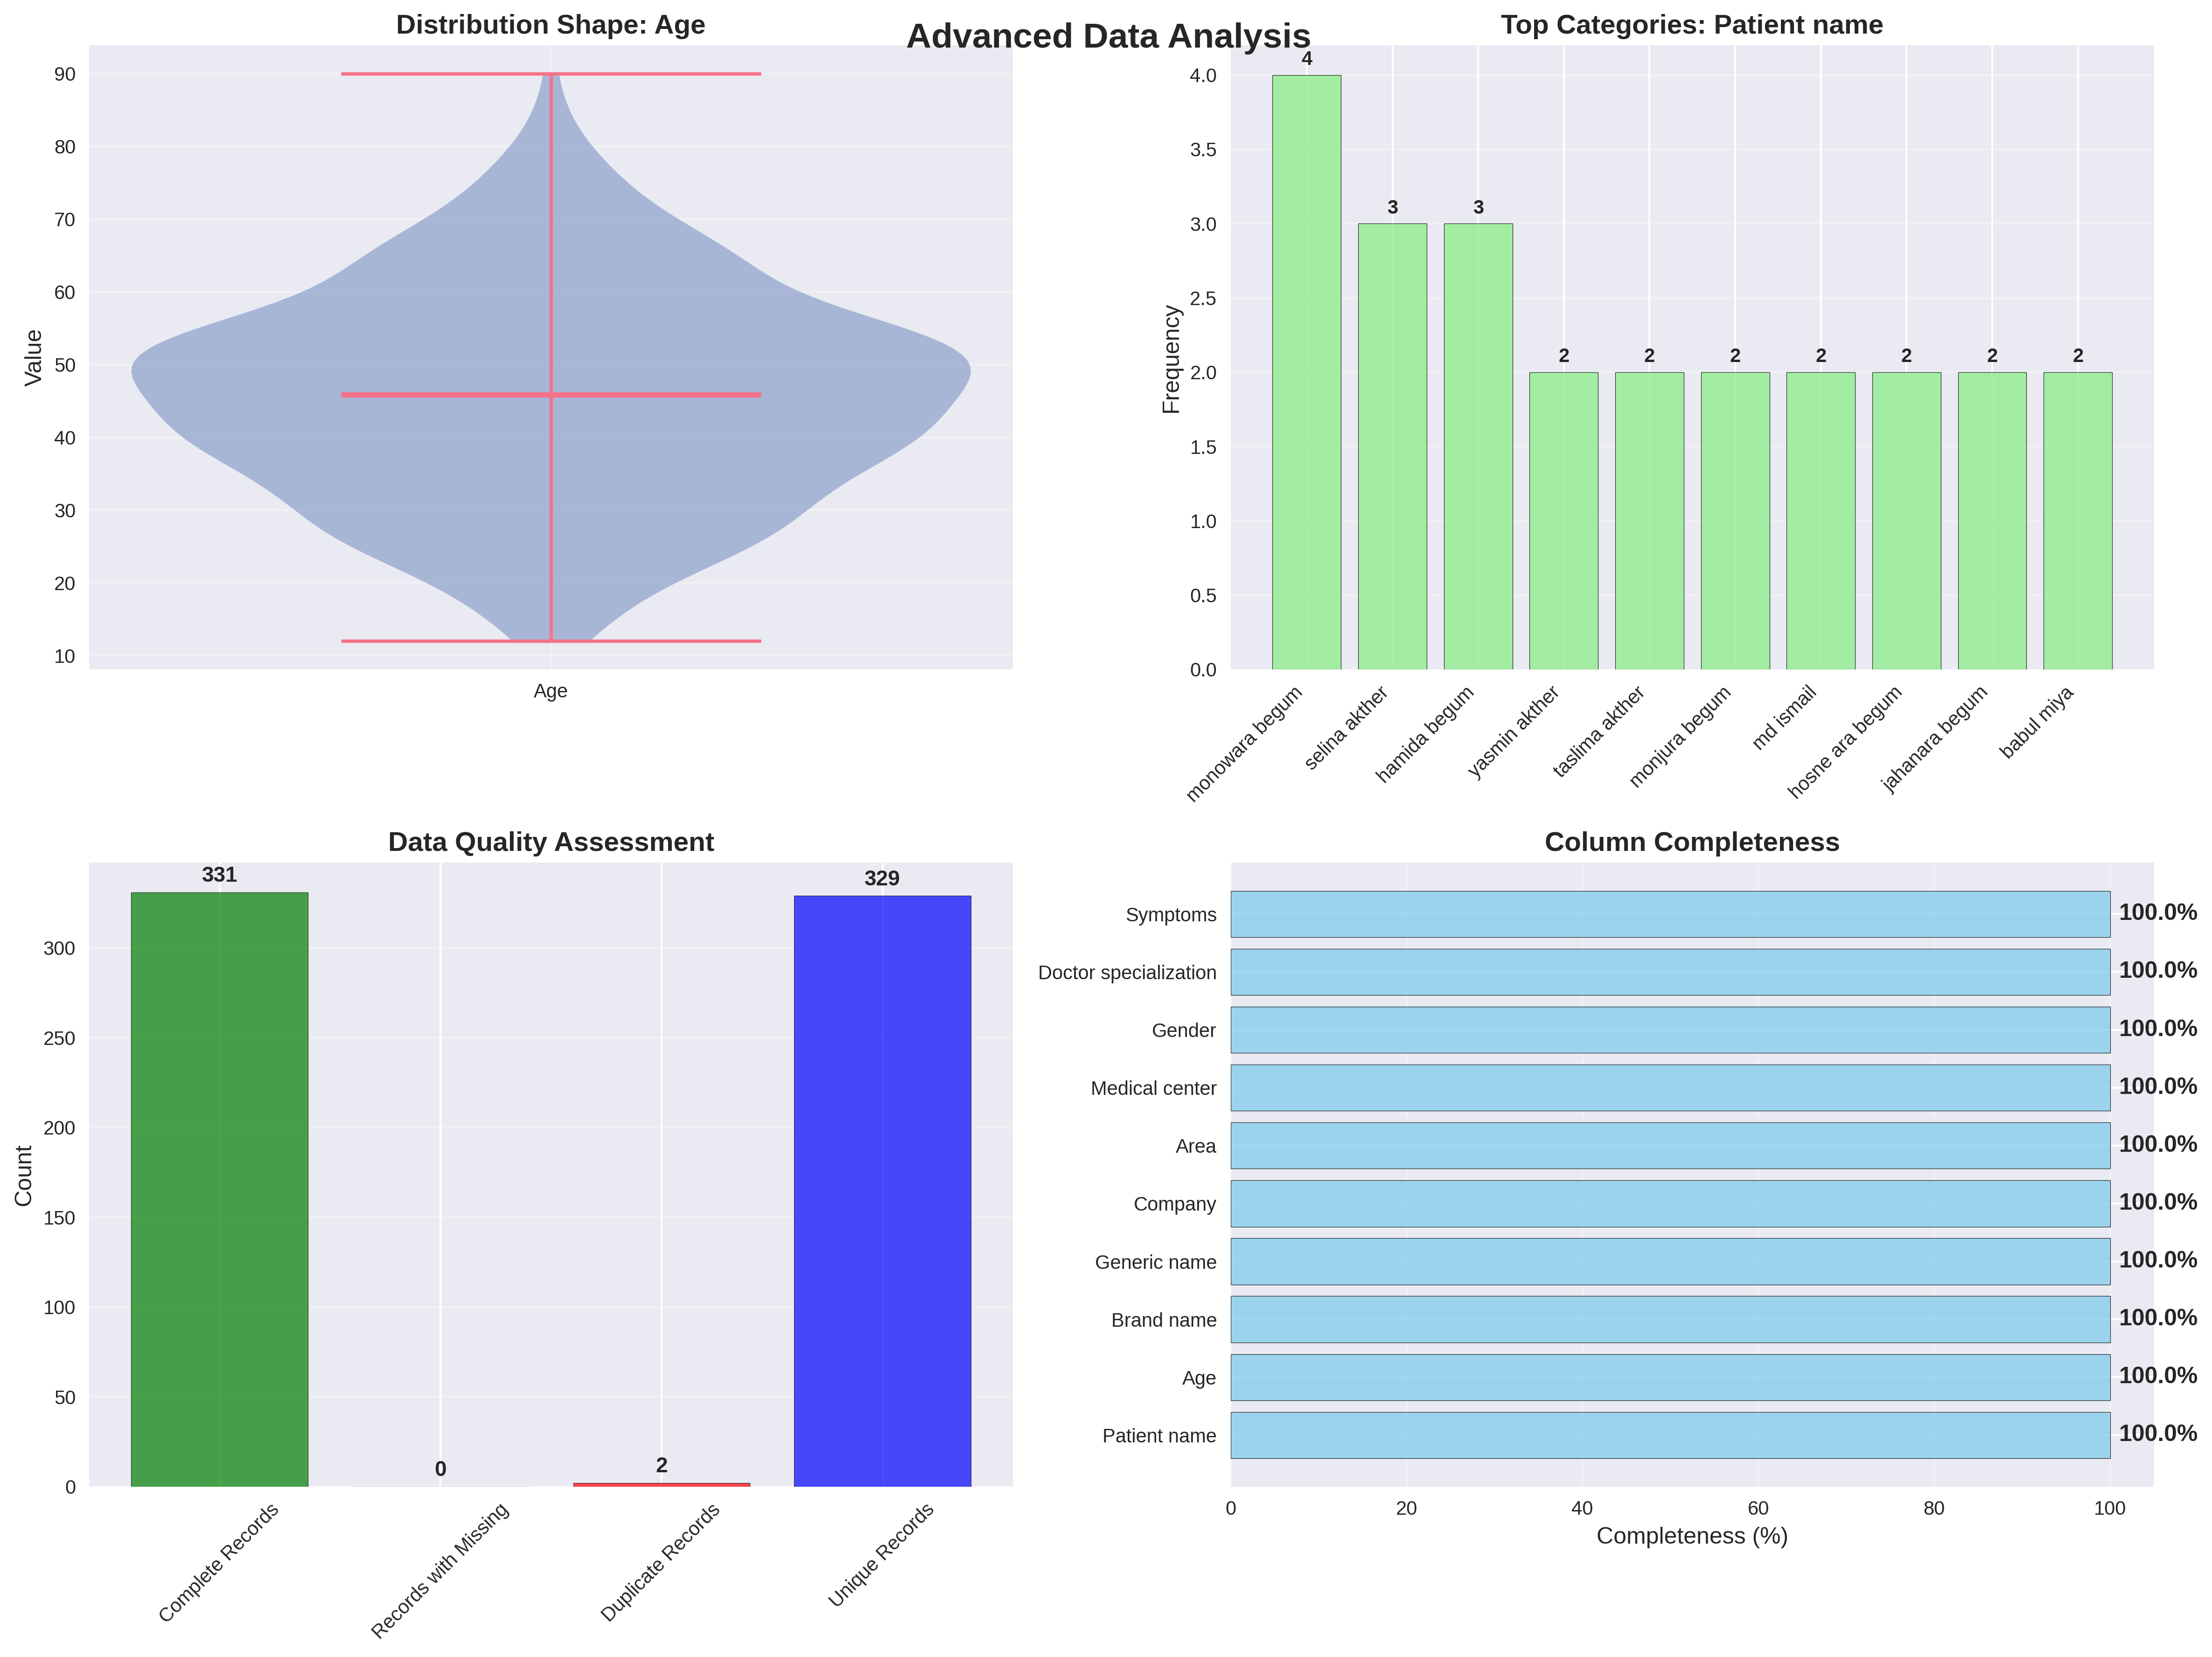

In [15]:
# Publication-ready figure 2: Advanced analysis plots
if len(numerical_cols) > 0 and len(categorical_cols) > 0:
    # Create subplots for advanced analysis
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Violin plot for first numerical variable
    first_num = numerical_cols[0]
    data_for_violin = df[first_num].dropna()
    
    parts = ax1.violinplot([data_for_violin], positions=[1], showmeans=True, showmedians=True)
    ax1.set_xticks([1])
    ax1.set_xticklabels([first_num])
    ax1.set_ylabel('Value')
    ax1.set_title(f'Distribution Shape: {first_num}', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Customize violin plot colors
    for pc in parts['bodies']:
        pc.set_facecolor('#8da0cb')
        pc.set_alpha(0.7)
    
    # Plot 2: Top categories in first categorical variable
    if len(categorical_cols) > 0:
        first_cat = categorical_cols[0]
        top_categories = df[first_cat].value_counts().head(10)
        
        bars = ax2.bar(range(len(top_categories)), top_categories.values, 
                      color='lightgreen', alpha=0.8, edgecolor='black')
        ax2.set_xticks(range(len(top_categories)))
        ax2.set_xticklabels(top_categories.index, rotation=45, ha='right')
        ax2.set_ylabel('Frequency')
        ax2.set_title(f'Top Categories: {first_cat}', fontsize=14, fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='y')
        
        # Add value labels
        for bar, value in zip(bars, top_categories.values):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(top_categories)*0.01,
                    str(value), ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Plot 3: Data quality assessment
    quality_metrics = {
        'Complete Records': len(df.dropna()),
        'Records with Missing': len(df) - len(df.dropna()),
        'Duplicate Records': df.duplicated().sum(),
        'Unique Records': len(df) - df.duplicated().sum()
    }
    
    colors = ['green', 'orange', 'red', 'blue']
    bars = ax3.bar(quality_metrics.keys(), quality_metrics.values(), 
                  color=colors, alpha=0.7, edgecolor='black')
    ax3.set_ylabel('Count')
    ax3.set_title('Data Quality Assessment', fontsize=14, fontweight='bold')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bar, value in zip(bars, quality_metrics.values()):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(quality_metrics.values())*0.01,
                str(value), ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    # Plot 4: Column completeness
    completeness = ((df.count() / len(df)) * 100).sort_values(ascending=True)
    bars = ax4.barh(range(len(completeness)), completeness.values, 
                   color='skyblue', alpha=0.8, edgecolor='black')
    ax4.set_yticks(range(len(completeness)))
    ax4.set_yticklabels(completeness.index)
    ax4.set_xlabel('Completeness (%)')
    ax4.set_title('Column Completeness', fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3, axis='x')
    
    # Add percentage labels
    for i, (bar, value) in enumerate(zip(bars, completeness.values)):
        ax4.text(value + 1, i, f'{value:.1f}%', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.suptitle('Advanced Data Analysis', fontsize=18, fontweight='bold', y=0.98)
    save_plot("publication_advanced", fig)
    plt.show()
else:
    print("Advanced analysis requires both numerical and categorical variables.")

## 7. Export Visualizations

Save all generated charts and graphs in high-resolution formats for research publications.

In [16]:
# Summary of exported files
print("EXPORT SUMMARY:")
print("="*50)
print(f"Output directory: {output_dir.absolute()}")
print("\nGenerated files:")

# List all files in the output directory
if output_dir.exists():
    files = list(output_dir.glob("*"))
    if files:
        for file in sorted(files):
            print(f"  📊 {file.name}")
        
        print(f"\nTotal files generated: {len(files)}")
        print(f"File formats: PNG (high-resolution), PDF (vector graphics)")
        print("\nThese files are ready for inclusion in research publications!")
    else:
        print("  No files found in output directory")
else:
    print("  Output directory not found")

# Generate a summary report
print("\n" + "="*60)
print("RESEARCH INSIGHTS SUMMARY:")
print("="*60)

insights = []

# Dataset size insights
insights.append(f"• Dataset contains {len(df):,} records with {len(df.columns)} variables")

# Variable type insights
if len(numerical_cols) > 0:
    insights.append(f"• {len(numerical_cols)} numerical variables suitable for statistical analysis")
if len(categorical_cols) > 0:
    insights.append(f"• {len(categorical_cols)} categorical variables for group comparisons")

# Data quality insights
missing_pct = (df.isnull().sum().sum() / (len(df) * len(df.columns))) * 100
insights.append(f"• Data completeness: {100-missing_pct:.1f}% ({df.isnull().sum().sum():,} missing values)")

if df.duplicated().sum() > 0:
    insights.append(f"• {df.duplicated().sum()} duplicate records identified ({(df.duplicated().sum()/len(df)*100):.1f}%)")
else:
    insights.append("• No duplicate records found")

# Correlation insights
if len(numerical_cols) > 1:
    corr_matrix = df[numerical_cols].corr()
    high_corr = 0
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.7:
                high_corr += 1
    
    if high_corr > 0:
        insights.append(f"• {high_corr} highly correlated variable pairs (|r| > 0.7) detected")
    else:
        insights.append("• No strong correlations (|r| > 0.7) between numerical variables")

for insight in insights:
    print(insight)

print("\n" + "="*60)
print("RECOMMENDATIONS FOR RESEARCH PAPER:")
print("="*60)
print("1. Include the dataset overview figure in the methodology section")
print("2. Use distribution plots to describe variable characteristics")
print("3. Report correlation findings in the results section")
print("4. Consider data quality metrics in limitations discussion")
print("5. Use high-resolution PNG files for online publication")
print("6. Use PDF files for print publication to maintain vector quality")

EXPORT SUMMARY:
Output directory: /home/dodopc/Documents/bijoy/analysis_plots

Generated files:
  📊 box_plots.pdf
  📊 box_plots.png
  📊 categorical_distributions.pdf
  📊 categorical_distributions.png
  📊 numerical_distributions.pdf
  📊 numerical_distributions.png
  📊 publication_advanced.pdf
  📊 publication_advanced.png
  📊 publication_overview.pdf
  📊 publication_overview.png

Total files generated: 10
File formats: PNG (high-resolution), PDF (vector graphics)

These files are ready for inclusion in research publications!

RESEARCH INSIGHTS SUMMARY:
• Dataset contains 331 records with 10 variables
• 1 numerical variables suitable for statistical analysis
• 9 categorical variables for group comparisons
• Data completeness: 100.0% (0 missing values)
• 2 duplicate records identified (0.6%)

RECOMMENDATIONS FOR RESEARCH PAPER:
1. Include the dataset overview figure in the methodology section
2. Use distribution plots to describe variable characteristics
3. Report correlation findings in t